# Data Mining Workflow based on "Hulk-NoDefense" Dataset

# Project Overview:

This project implements the complete workflow for training a machine learning model using the **"Hulk-NoDefense"** dataset, collected by the Department of Engineering at **Università del Sannio**. 


## Dataset Description
The **"Hulk-NoDefense"** dataset comprises monitored connections of various servers during a **Hulk attack**. **Hulk attack**, or HTTP Unbearable Load King, is a denial-of-service (DoS) attack method that aims to overwhelm a web server by generating numerous unique and seemingly legitimate requests to exhaust server resources. 

## Features Meaning:
- **Fwd**: Forwarded - Refers to packets sent in the forward direction (from the source to the destination).
- **Bwd**: Backwarded - Refers to packets sent in the reverse direction (from the destination to the source).
- **IAT**: Inter Arrival Time - The time between the arrival of consecutive packets.
- **PSH**: Push - A flag in the TCP header that forces the delivery of data without waiting for a buffer to fill.
- **URG**: Urgent - A flag in the TCP header indicating that the packet contains urgent data.
- **FIN**: Finish - A TCP flag used to indicate the termination of a connection.
- **SYN**: Synchronize - A TCP flag used to initiate a connection between two hosts.
- **RST**: Reset - A TCP flag used to reset a connection when an error or unexpected situation occurs.
- **ACK**: Acknowledgment - A TCP flag used to acknowledge the receipt of data.
- **CWR**: Congestion Window Reduced - A TCP flag indicating that the sender has reduced its transmission rate to alleviate network congestion.
- **ECE**: Explicit Congestion Notification Echo - A TCP flag indicating that the network is experiencing congestion.
- **Bulk**: Bulk Data Transfer - Refers to the transfer of a large volume of data in a network connection.
- **Init Win**: Initial Window - The size of the congestion window at the start of a TCP connection.
- **Active**: Active Time - The duration for which a connection remains active.
- **Idle**: Idle Time - The duration for which a connection remains idle, without data transmission.

## Workflow Steps

1. **Goal Definition**
    - Define the objectives and scope of the project.
    
2. **Data Collection**
    - Obtain the "Hulk-NoDefense" dataset.
3. **Data Exploration**
    - Analyze the dataset to understand its structure and contents.
    - Identify correlations, and potential anomalies in the data.

4. **Data Preprocessing**
   - Handle missing values, duplicates, and outliers.
   - Implement techniques for rebalancing the dataset.
   - Normalize or scale features as needed.

5. **Model Training with Features Analysis**
   - Conduct feature importance analysis to identify key attributes.
   - Adopt a dimensionality reduction method

6. **Models Evaluation**
   - Evaluate different trained models using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
   - Compare models to select the best-performing approach.

---


# Step 0: Goal Definition

### The overall goal
The goal of this project is to train a machine learning model to accurately classify malicious internet connections involved in a particular DoS attack called **Hulk** from legitimate ones. Moreover, the objective is to identify the key features and analyze how the model's performance changes when these features are not provided.

# Step 1: Data Collection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = 'src/Hulk-NoDefense.csv'
chunk_size = 10000
chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunks.append(chunk)


df_raw = pd.concat(chunks, ignore_index=True)

# Step 2: Data Exploration

## Numerical Exploration

In [2]:
print(f"The number of istances in the dataset are {df_raw.shape[0]}, the number of features are {df_raw.shape[1]}")
display(df_raw.head())
print("Dataset information")
display(df_raw.info())

pd.set_option('display.max_columns', None)
print("Dataset description")
display(df_raw.describe())


The number of istances in the dataset are 851173, the number of features are 84


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.111.65-192.168.111.66-34700-80-6,192.168.111.65,34700,192.168.111.66,80,6,11/02/2021 09:03:53 AM,1397,7,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hulk-NoDefense
1,192.168.111.65-192.168.111.66-34702-80-6,192.168.111.65,34702,192.168.111.66,80,6,11/02/2021 09:03:53 AM,1438,7,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hulk-NoDefense
2,192.168.111.65-192.168.111.66-34704-80-6,192.168.111.65,34704,192.168.111.66,80,6,11/02/2021 09:03:53 AM,1753,7,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hulk-NoDefense
3,192.168.111.65-192.168.111.66-34706-80-6,192.168.111.65,34706,192.168.111.66,80,6,11/02/2021 09:03:53 AM,3166,7,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hulk-NoDefense
4,192.168.111.65-192.168.111.66-34708-80-6,192.168.111.65,34708,192.168.111.66,80,6,11/02/2021 09:03:53 AM,1094,9,7,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hulk-NoDefense


Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851173 entries, 0 to 851172
Data columns (total 84 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     851173 non-null  object 
 1   Src IP                      851173 non-null  object 
 2   Src Port                    851173 non-null  int64  
 3   Dst IP                      851173 non-null  object 
 4   Dst Port                    851173 non-null  int64  
 5   Protocol                    851173 non-null  int64  
 6   Timestamp                   851173 non-null  object 
 7   Flow Duration               851173 non-null  int64  
 8   Total Fwd Packet            851173 non-null  int64  
 9   Total Bwd packets           851173 non-null  int64  
 10  Total Length of Fwd Packet  851173 non-null  float64
 11  Total Length of Bwd Packet  851173 non-null  float64
 12  Fwd Packet Length Max       851173 non-null  float64

None

Dataset description


C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,851173.000000,851173.000000,851173.000000,8.511730e+05,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,8.511730e+05,8.511730e+05,8.511700e+05,8.511700e+05,8.511700e+05,8.511700e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,851173.000000,851173.000000,851173.0,851173.0,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,8.511730e+05,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.0,851173.0,851173.0,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,8.511730e+05,851173.000000,851173.000000,851173.0,851173.000000,851173.000000,851173.000000,851173.000000,851173.000000,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05,8.511730e+05
mean,46823.487011,79.997582,5.999973,6.571313e+05,7.428482,5.444663,363.144443,11261.580294,360.420926,0.002925,49.670427,133.426540,6275.037164,0.000150,2136.806527,2747.182634,inf,inf,5.378093e+04,1.528875e+05,5.270580e+05,9.978262e+01,6.571313e+05,9.790896e+04,2.018790e+05,5.270583e+05,1.521716e+02,2.272711e+05,4.512836e+04,9.721065e+04,2.236218e+05,1.911729e+02,1.006250,1.006289,0.0,0.0,245.534724,182.280979,63.678385,49.762641,0.002925,6275.047412,923.143807,1980.007861,4.241193e+06,1.006826,2.012946,1.014640,2.012539,11.854263,0.0,0.0,0.0,0.728646,923.143807,49.670427,2136.806527,0.008582,0.000025,0.005555,3507.715513,1.272476,1.335028e+07,0.000043,28.371664,0.0,893.834819,29198.631169,260.711637,1.006711,31.917836,5.077140e+03,8.999750e+01,5.175367e+03,4.991934e+03,1.298116e+05,7.323328e+01,1.298871e+05,1.297275e+05
std,8147.733201,0.474180,0.050782,1.374346e+06,1.680151,1.027511,75.235192,1043.783958,31.785153,0.881448,8.218687,14.776270,1693.330884,0.098104,442.081909,1024.244359,NaN,NaN,8.875462e+04,2.784184e+05,1.125814e+06,2.613776e+04,1.374346e+06,1.455426e+05,3.686321e+05,1.125812e+06,2.613979e+04,9.465909e+05,1.261246e+05,3.248776e+05,9.204193e+05,7.482252e+03,0.095892,0.097716,0.0,0.0,34.449938,33.109907,510.710232,414.656079,0.881448,1693.295838,154.614567,566.359089,2.860027e+06,0.093683,0.161507,0.135755,0.193097,2.052847,0.0,0.0,0.0,0.046643,154.614567,8.218687,442.081909,3.563907,0.010226,2.345043,5191.745319,1.888719,2.214236e+07,0.006593,5.451912,0.0,149.861539,199.684410,847.724661,0.200296,1.001621,9.163638e+04,3.866120e+04,1.194006e+05,7.546781e+04,1.118505e+06,3.564093e+04,1.120366e+06,1.117260e+06
min,0.000000,0.0000

**Null rows**

In [14]:
display(df_raw[df_raw.isnull().any(axis=1)])

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
486712,192.168.111.6-192.168.111.255-138-138-17,192.168.111.6,138,192.168.111.255,138,17,11/02/2021 09:07:06 AM,0,1,0,183.0,0.0,183.0,183.0,183.0,0.0,0.0,0.0,0.0,0.0,inf,inf,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,8,0,0.0,0.0,183.0,183.0,183.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,183.0,183.0,0.0,0,0,0,0,0,0,1,183,0,0,0,0,0,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
702344,192.168.111.6-192.168.111.255-138-138-17,192.168.111.6,138,192.168.111.255,138,17,11/02/2021 09:09:34 AM,0,1,0,201.0,0.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,inf,inf,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,8,0,0.0,0.0,201.0,201.0,201.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,201.0,201.0,0.0,0,0,0,0,0,0,1,201,0,0,0,0,0,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
837046,192.168.111.199-192.168.111.255-138-138-17,192.168.111.199,138,192.168.111.255,138,17,11/02/2021 09:07:44 AM,0,1,0,206.0,0.0,206.0,206.0,206.0,0.0,0.0,0.0,0.0,0.0,inf,inf,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,8,0,0.0,0.0,206.0,206.0,206.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,206.0,206.0,0.0,0,0,0,0,0,0,1,206,0,0,0,0,0,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [4]:
label_values = df_raw['Label'].unique()
print("Values of column 'Label' :", label_values)

Values of column 'Label' : ['Hulk-NoDefense' 'BENIGN']


**Numerical columns with value equal to 0 or variance equal to 0**

In [15]:
numeric_columns = df_raw.select_dtypes(include=['number']).columns
zero_columns = [col for col in numeric_columns if (df_raw[col] == 0).all()]
zero_var_columns = [col for col in numeric_columns if df_raw[col].var() == 0]

print("Columns with all values equal to zero (numeric only):", zero_columns)
print("Columns with variance equal to zero (numeric only):", zero_var_columns)


C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Columns with all values equal to zero (numeric only): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Subflow Bwd Packets']
Columns with variance equal to zero (numeric only): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Subflow Bwd Packets']


**Relation between categorical field and target feature**

In [6]:
from scipy.stats import chi2_contingency
categorical_field = df_raw.select_dtypes(exclude=['number']).columns
categorical_field = categorical_field.drop('Label')
categorical_field = categorical_field.drop('Flow ID')
def chi_square_test(df, categorical_field, target):
    chi_square_results = {}
    # Itera su ciascuna delle feature categoriche
    for feature in categorical_field:
        # Crea una tabella di contingenza (cross-tabulation) per la feature e il target
        contingency_table = pd.crosstab(df[feature], df[target])
        
        # Applica il test del chi-quadrato
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        # Salva i risultati (p-value)
        chi_square_results[feature] = p_value
    
    return chi_square_results

# Supponiamo che il tuo DataFrame si chiami `df`
chi_square_results = chi_square_test(df_raw, categorical_field, 'Label')
print(chi_square_results)

{'Src IP': 0.0, 'Dst IP': 0.0, 'Timestamp': 0.0}


### Numerical Results

From the numerical exploration of the dataset, we observe that it consists of 851,173 instances defined by 84 features. These features include both numerical and categorical data, with the "Label" feature providing the ground truth for the training phase.

The dataset contains three instances with anomalous values. Specifically, in all three cases, the "Flow packet/s" feature and the "Flow Bytes/s" features have a value of "inf", while the features "Flow IAT Mean," "Flow IAT Std," "Flow IAT Max," and "Flow IAT Min" have a value of "NaN." This behavior can be attributed to the "Flow Duration" being 0 in these instances, which may be due to an error during data collection or an extremely short connection, and to the "Total Fwd Packet" being 1, leading to the IAT (Inter Arrival Time) values equal to NaN.

Additionally, the features "Fwd URG Flags," "Bwd URG Flags," "URG Flag Count," "CWR Flag Count," "ECE Flag Count," and "Subflow Bwd Packets" are always 0 throughout the dataset and the categorical features "Src Ip", "Dst Ip", "Tiemstamp" are independent from the target. As such, they provide no useful information for the model.

In the preprocessing phase, it will be necessary to address these issues to ensure the dataset is clean and suitable for training.

## Visual Inspection

### Class Distribution with a Pie Plot

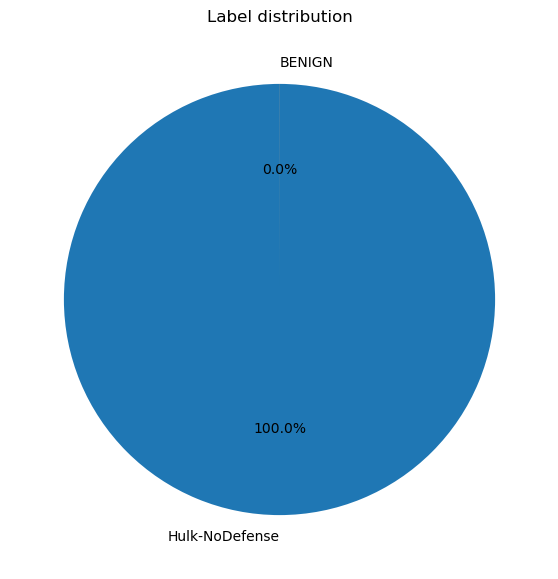

In [16]:
label_counts = df_raw['Label'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Label distribution')
plt.show()

### Scatter plot of the flow duration

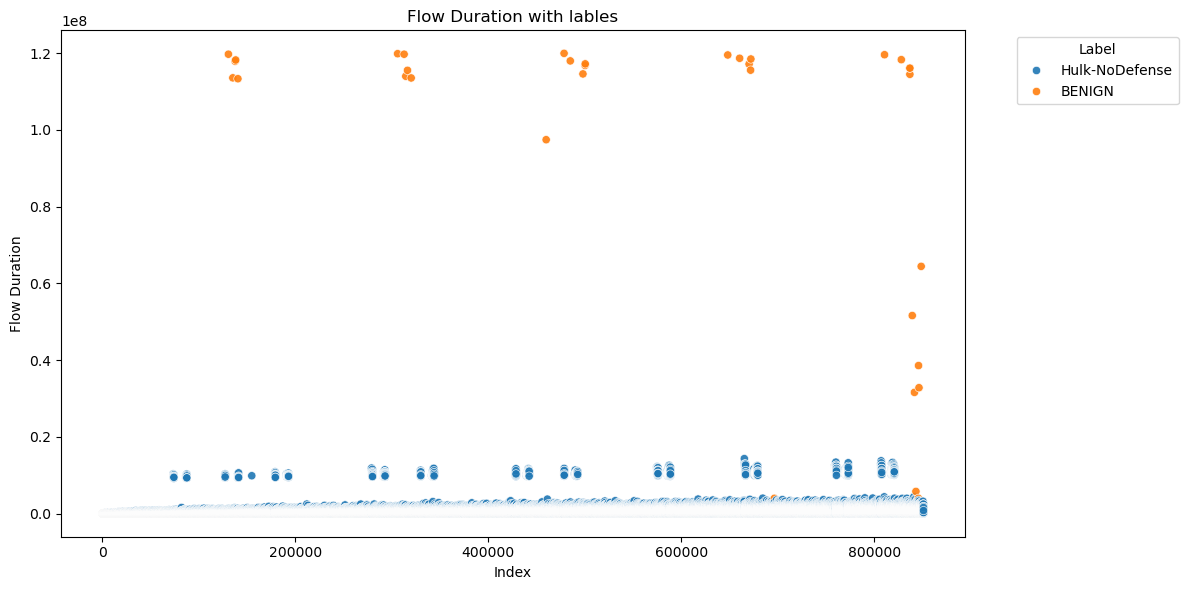

In [8]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_raw,
    x=range(len(df_raw)),  # Index
    y='Flow Duration',
    hue='Label',  
    palette='tab10',  
    alpha=0.9  
)

plt.title('Flow Duration with lables')
plt.xlabel('Index')
plt.ylabel('Flow Duration')
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')  # loc=legend position
plt.tight_layout()  # Better layout
plt.show()

### Histograms of numerical features

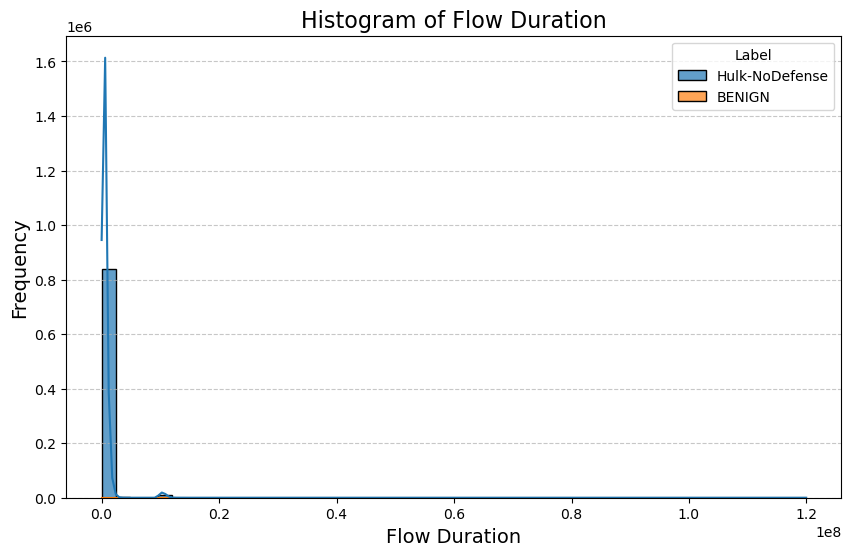

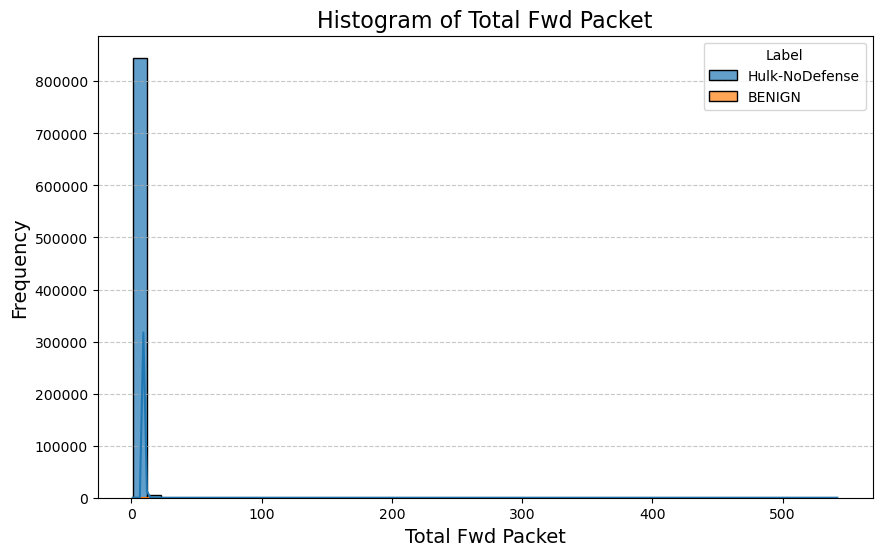

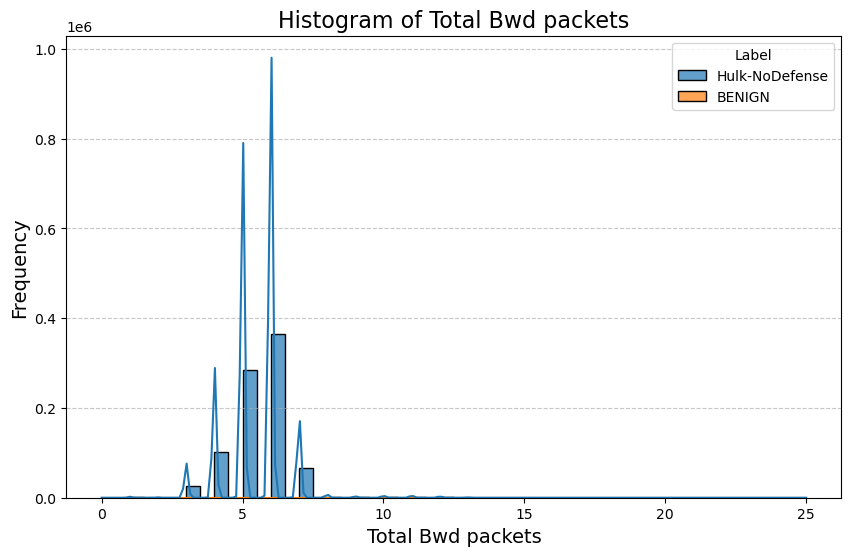

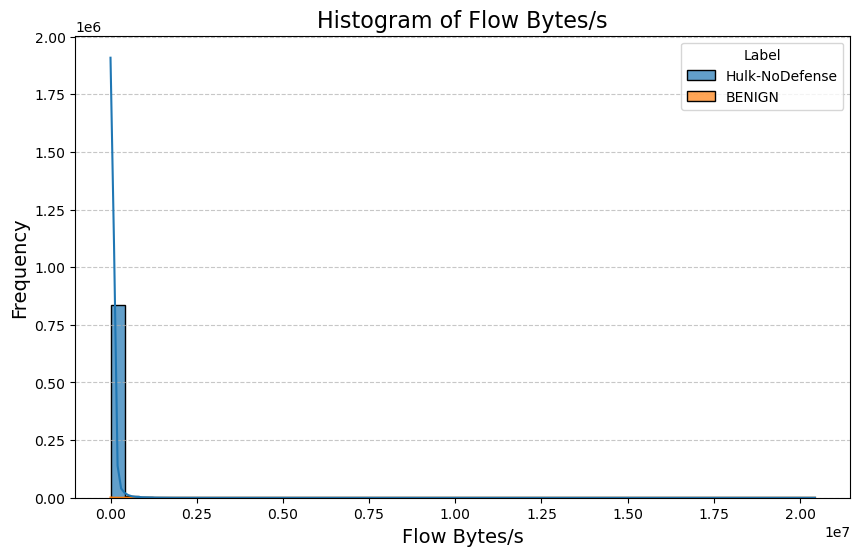

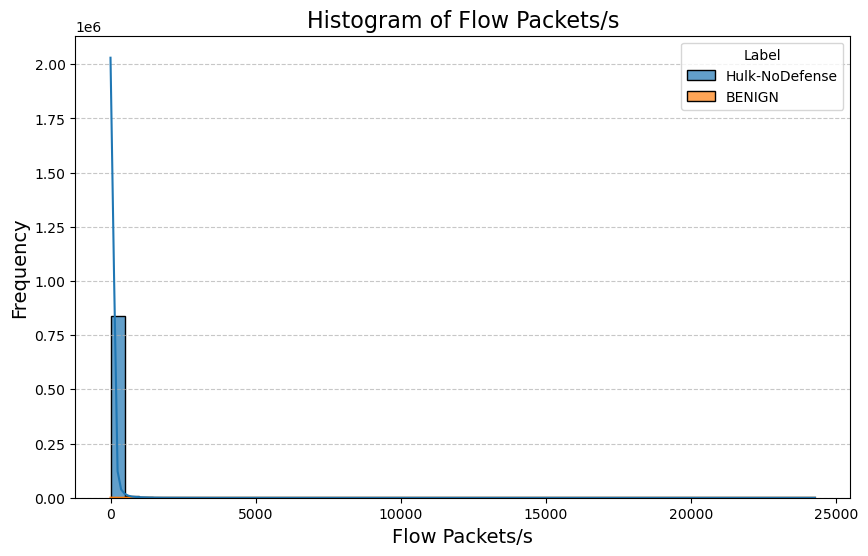

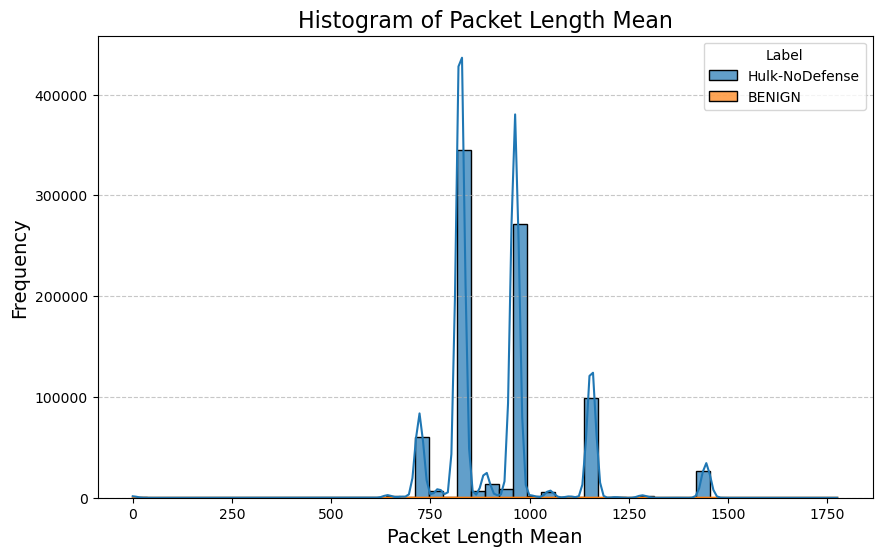

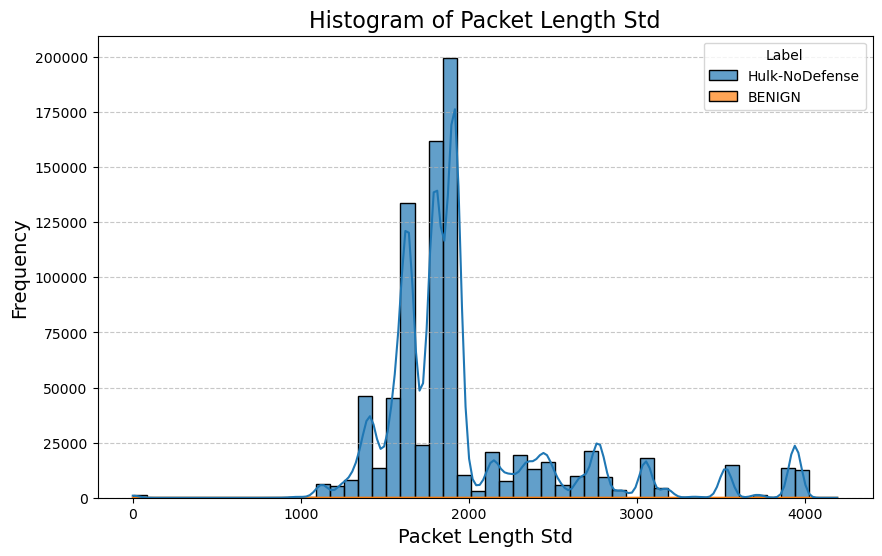

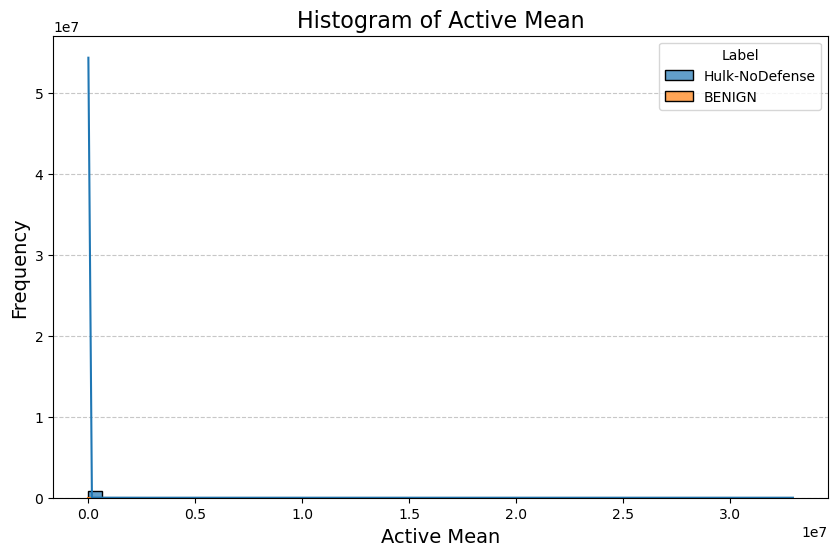

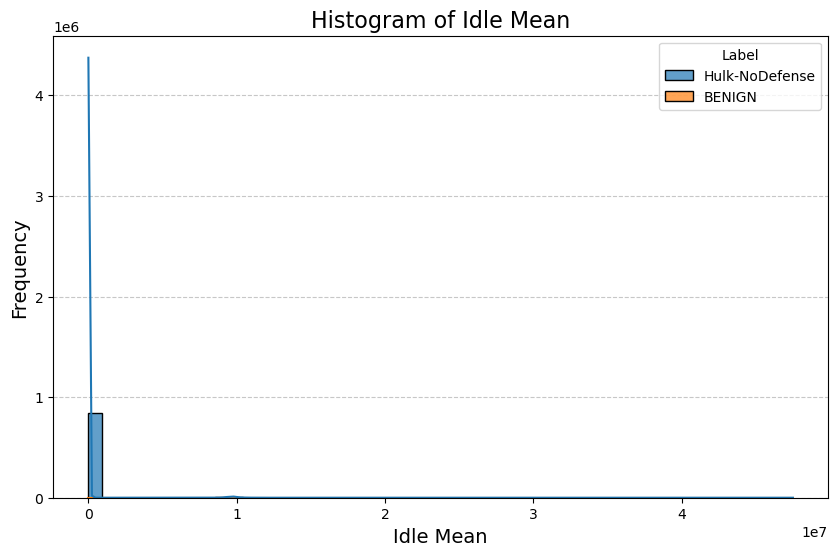

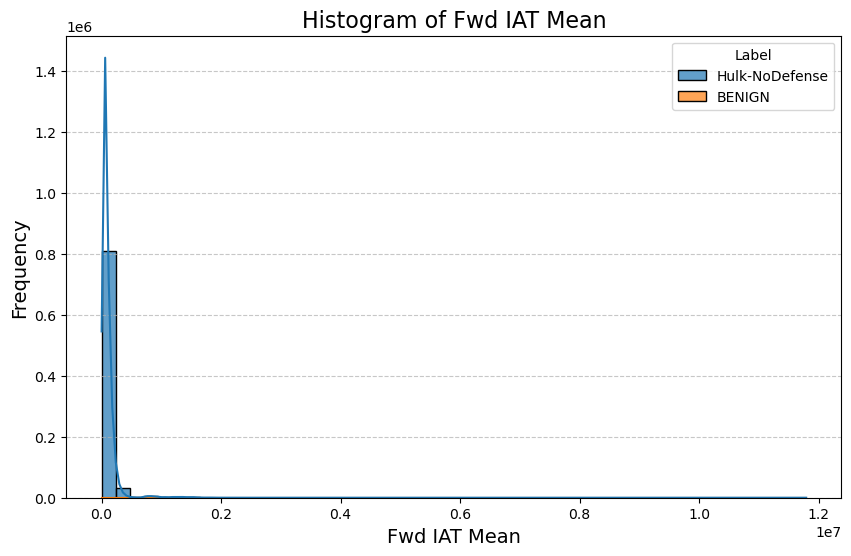

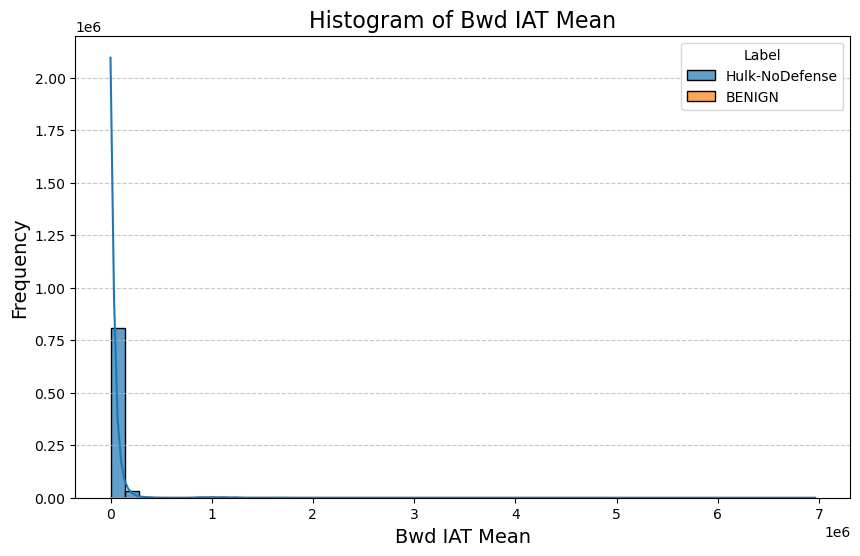

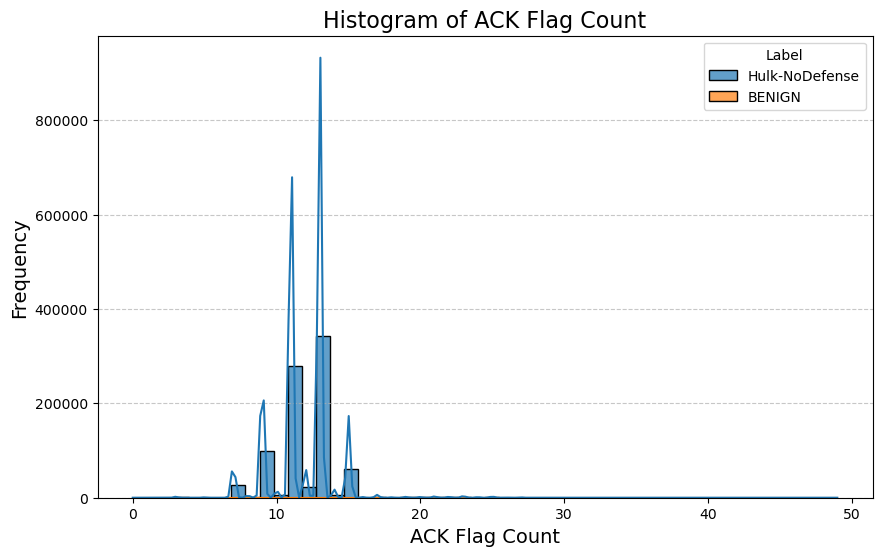

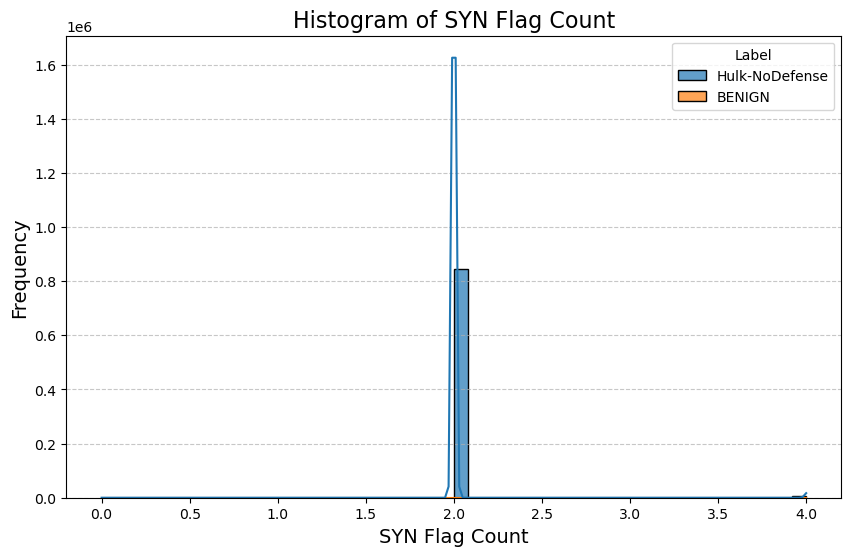

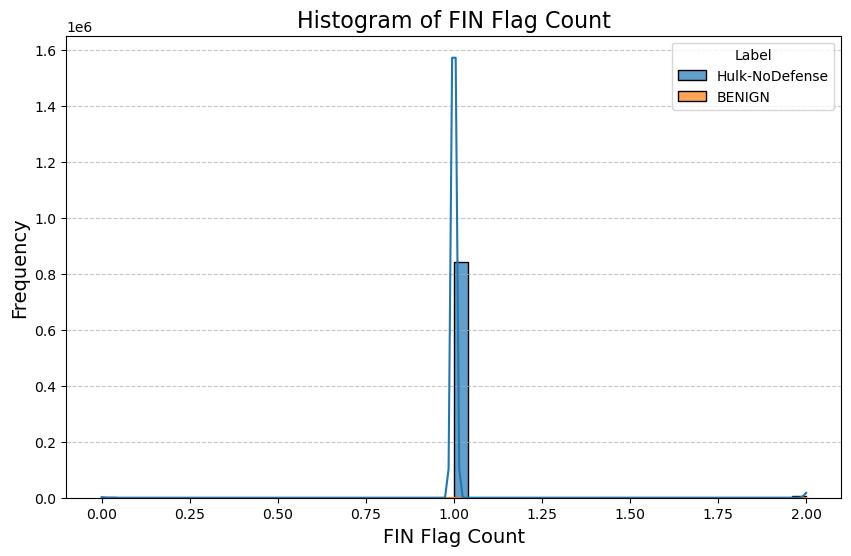

In [9]:
# Colonne selezionate
selected_columns = [
    'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 
    'Packet Length Std', 'Active Mean', 'Idle Mean', 
    'Fwd IAT Mean', 'Bwd IAT Mean', 'ACK Flag Count',
    'SYN Flag Count', 'FIN Flag Count'
]

# Creazione degli istogrammi
for col in selected_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_raw, x=col, bins=50, kde=True,hue='Label', palette='tab10', alpha=0.7)
    plt.title(f'Histogram of {col}', fontsize=16)
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()



### Series of scatter plot

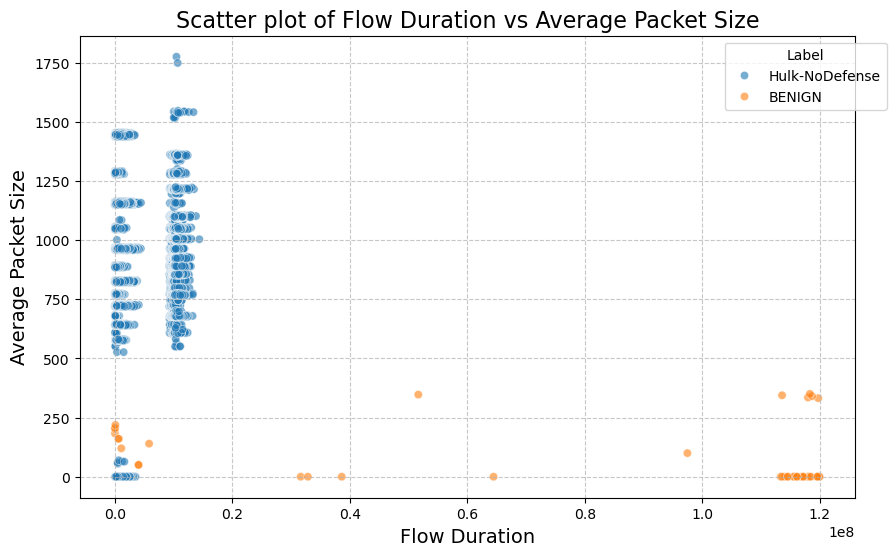

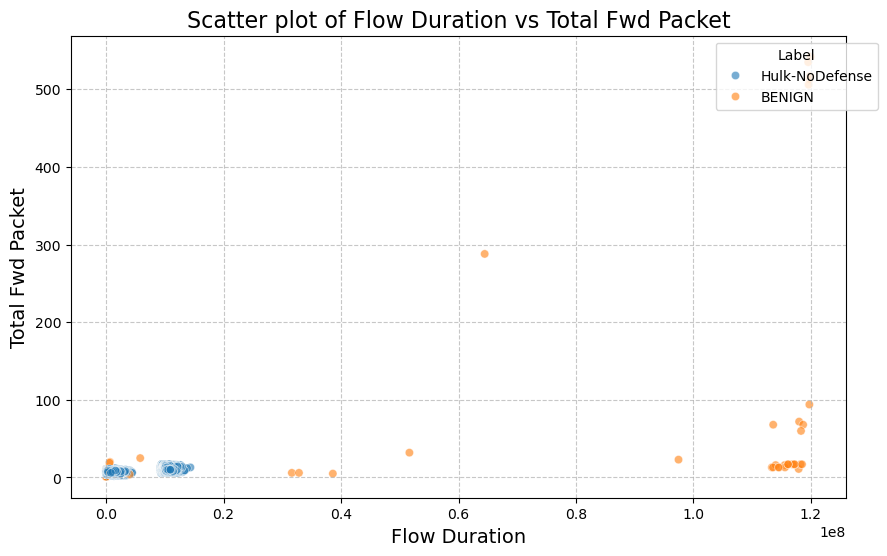

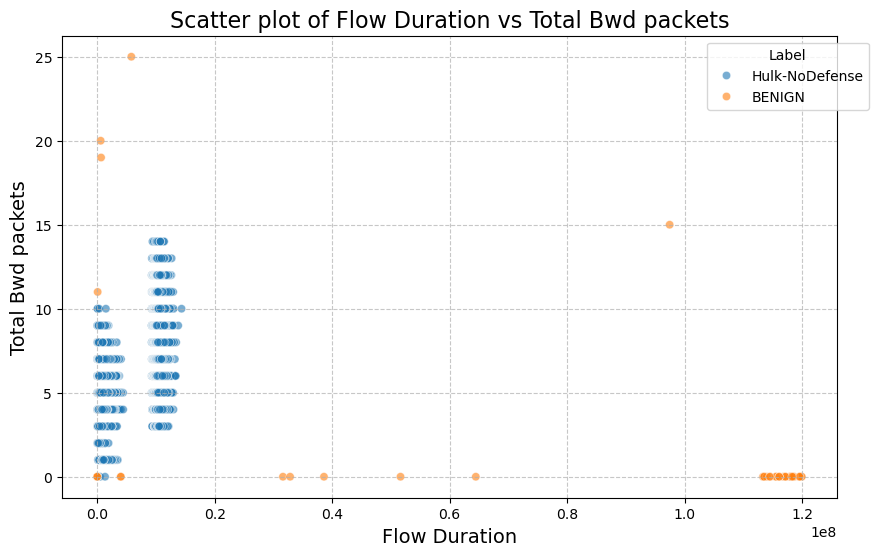

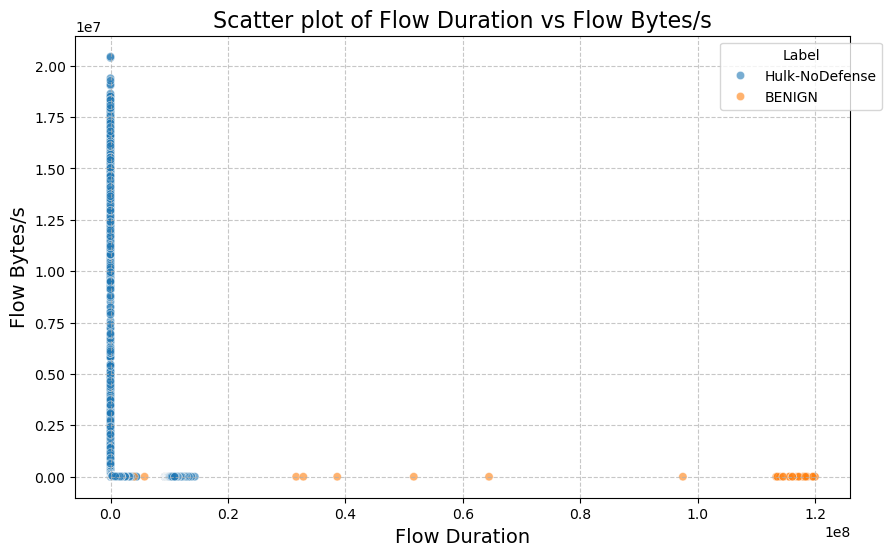

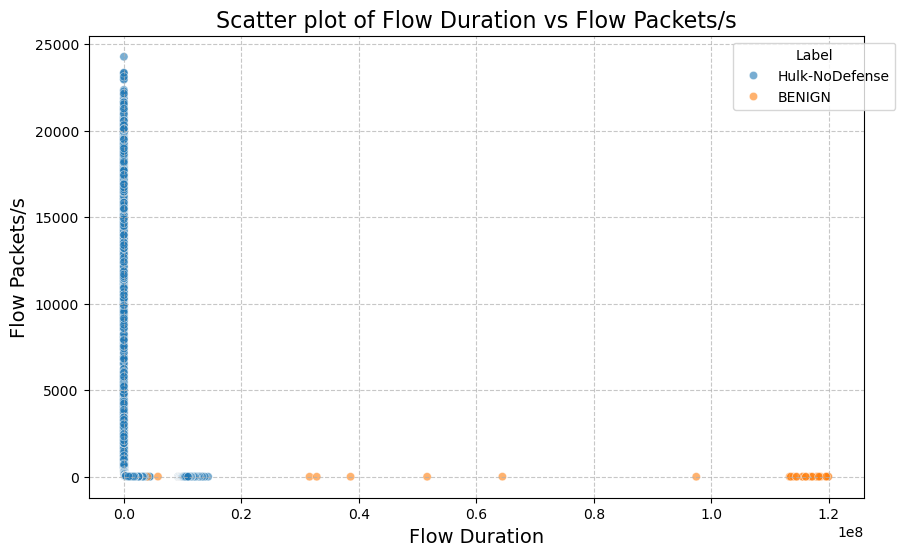

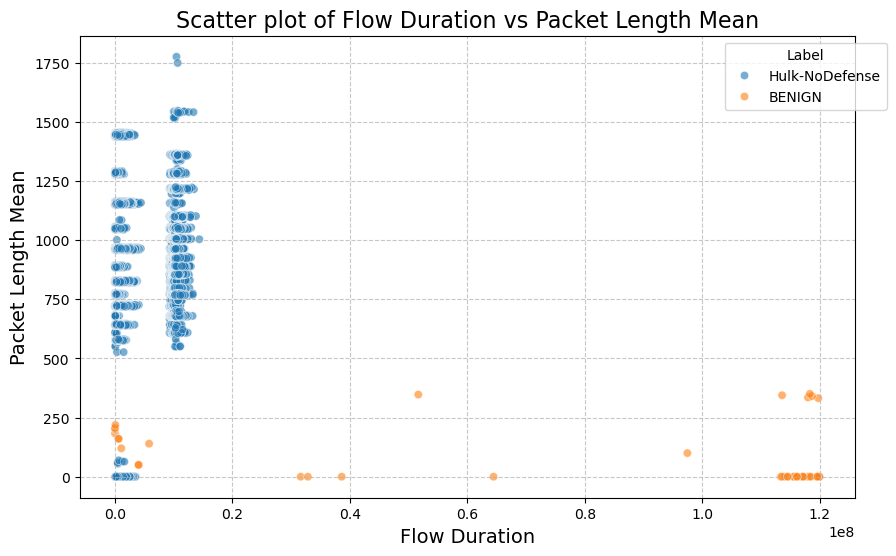

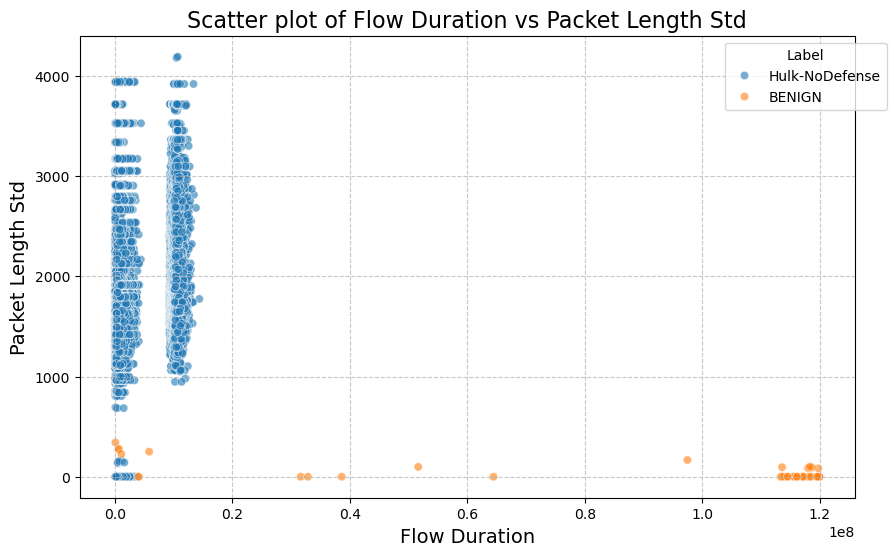

In [10]:
x_column = 'Flow Duration'

selected_columns = [
    'Average Packet Size', 'Total Fwd Packet', 'Total Bwd packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 
    'Packet Length Std'
]


for col in selected_columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_raw, x=x_column, y=col, alpha=0.6, hue='Label', palette='tab10')
    plt.title(f'Scatter plot of {x_column} vs {col}', fontsize=16)
    plt.xlabel(x_column, fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper right')  
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    plt.show()


### Box plot for distribution in different labels

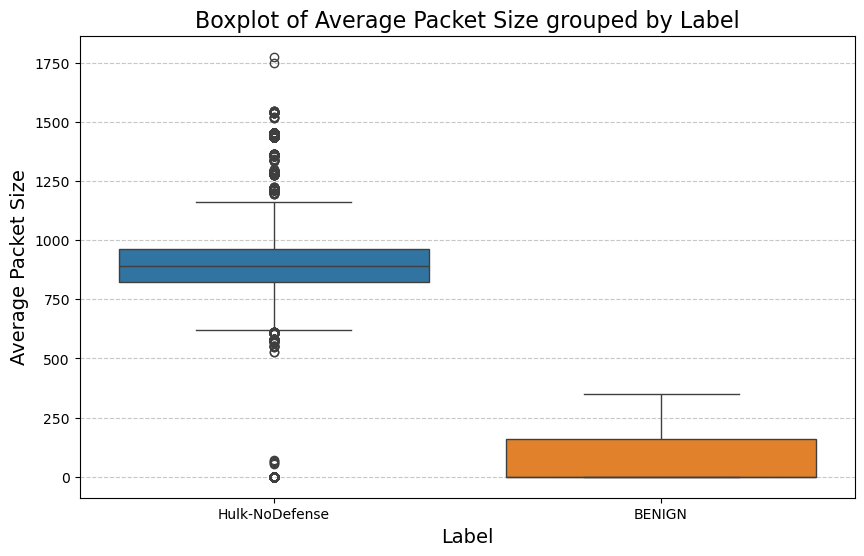

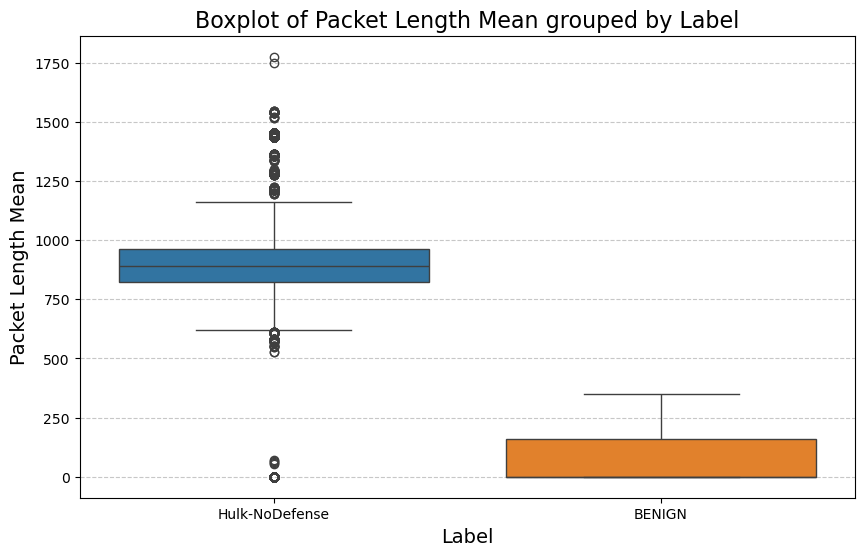

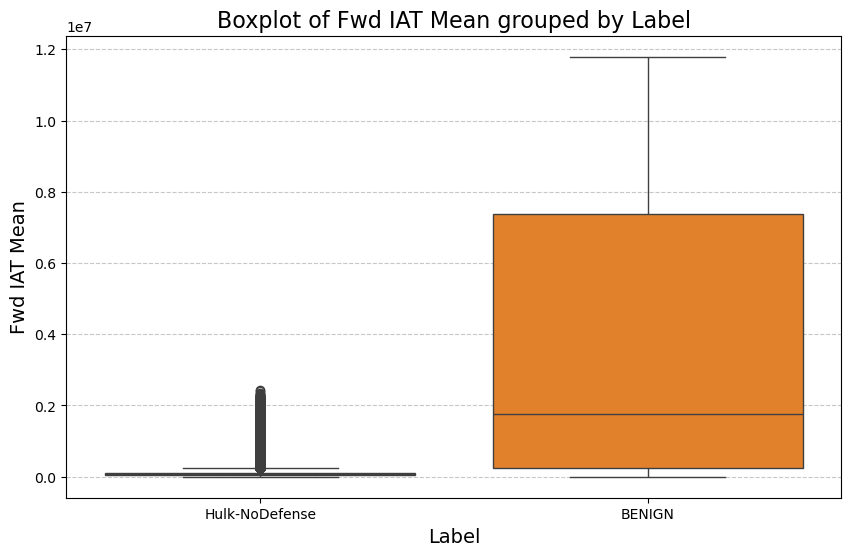

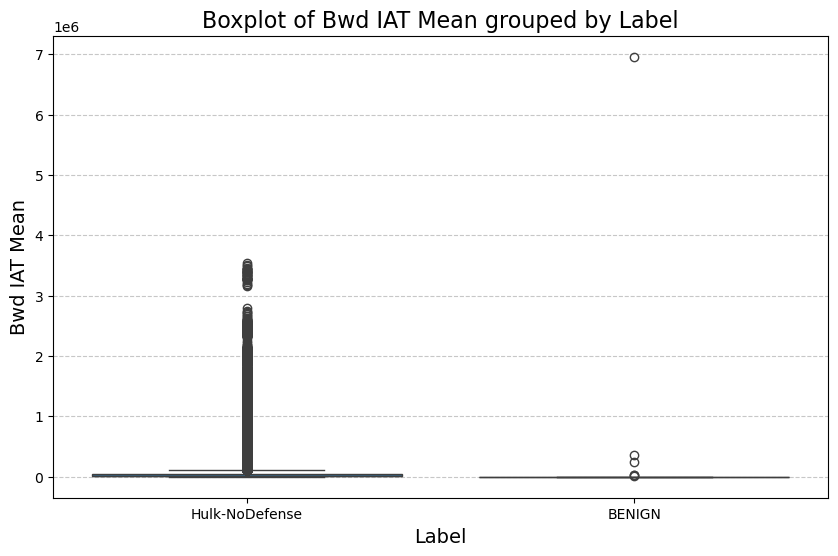

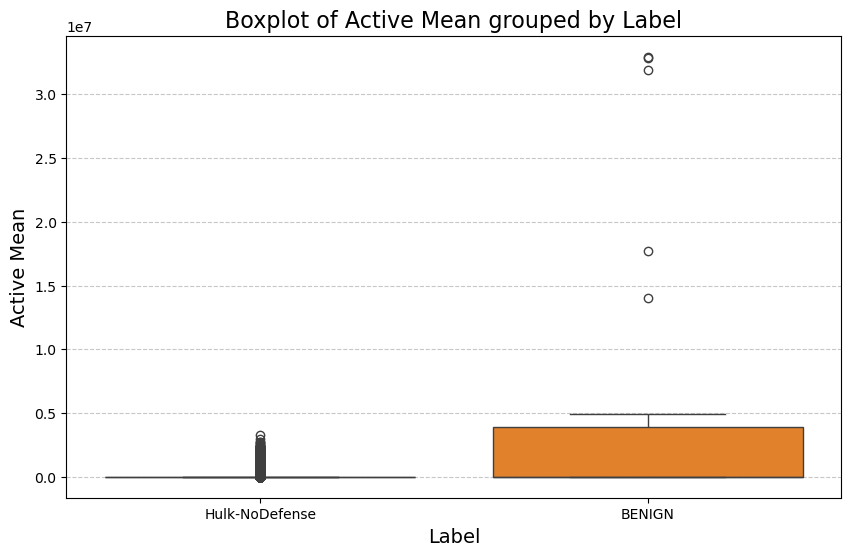

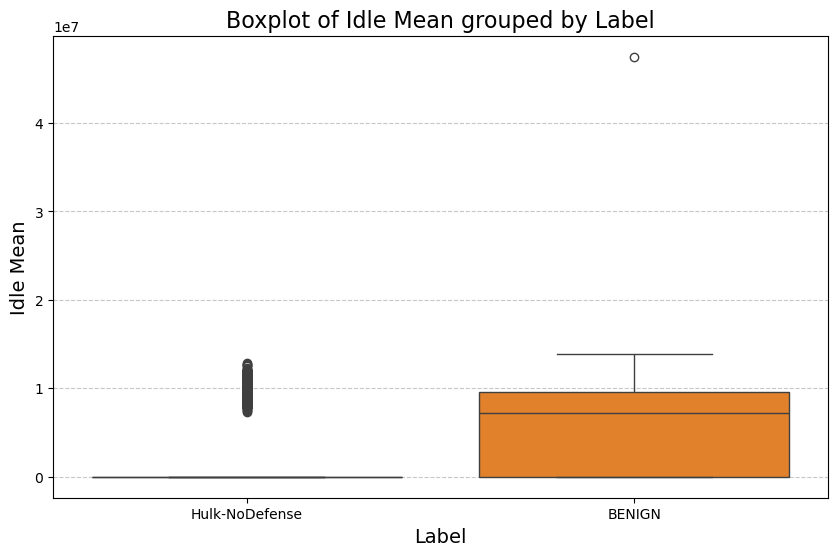

In [3]:
columns_for_boxplot = [
    'Average Packet Size', 'Packet Length Mean', 
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Active Mean', 'Idle Mean'
]

for col in columns_for_boxplot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_raw, x='Label', y=col, hue='Label', palette='tab10')  
    plt.title(f'Boxplot of {col} grouped by Label', fontsize=16)
    plt.xlabel('Label', fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend([], frameon=False) # no legend
    plt.show()


### Heat map of the correlation matrix

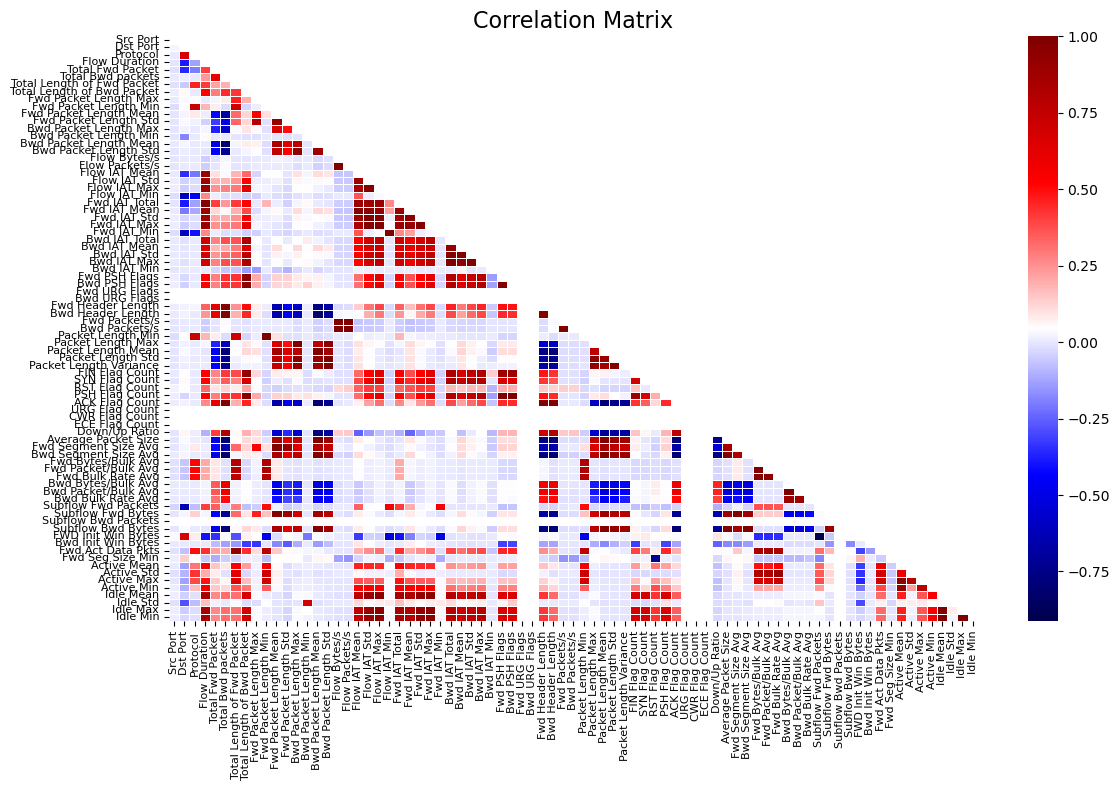

In [25]:

df_numeric = df_raw.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_numeric.corr()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='seismic',
    linewidths=0.7,
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns, 
)

plt.xticks(fontsize=8)  
plt.yticks(fontsize=8)  


plt.title('Correlation Matrix', fontsize=16)


plt.tight_layout()
plt.show()


### Visual Results

After the visual inspection it's possible to see that this dataset is strongly unbalanced, with the majority of the instances labeled as "Hulk-NoDefense" and the minority as "BENIGN". The majority class is characterized by a bigger packet size and a shorter flow duration, while in the minority class the packet are smaller but the connections last longer and the IAT (Inter Arrival Time) is bigger in general. 
From the correlation matrix it's possible to conclude that a lot of features are positively or negatively related. So we expect that, by using a feature selection method,  the performance will increase avoiding the "curse of dimensionality" problem.

# Expectations

After exploring the dataset, it becomes evident that there are several features that exhibit significant differences in their values when comparing instances from the two classes. This observation suggests that even a relatively simple model could perform well, as the distinction between the two classes appears to be clear and well-defined. Given this, the initial classifier chosen for the task is the Logistic Regressor.

The reason for selecting this model is threefold: first, the problem is a binary classification task, where the objective is to predict one of two possible outcomes. The Logistic Regressor is particularly well-suited for binary classification problems. Second, it is a relatively simple model that is easy to understand and interpret. This simplicity not only makes it a good starting point for the problem, but also allows for a transparent interpretation of the decision boundaries and the influence of each feature on the model’s predictions. Lastly, the Logistic Regressor is computationally efficient and does not require extensive resources or training time, making it well-suited for this scenario. Furthermore, the Logistic Regressor can be adjusted with regularization techniques, such as L1 or L2 regularization, which help mitigate the risk of overfitting.

It serves as a solid foundation from which further model refinements and more complex techniques can be explored if needed.